<h1><b>PREDIKSI KEMACETAN LALU LINTAS</b></h1>

<br>


<h2>Tahap 1 - Kumpulkan Data Relevan</h2>

<hr>




In [22]:
# ===============================
#         Load Dataset
# ===============================

# Import library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Ambil dataset dari github
url = 'https://raw.githubusercontent.com/plutomurus/trafic/main/dataset.csv'
raw_df = pd.read_csv(url, delimiter=',')

display(raw_df.iloc[0::2].head())

# Filter baris dengan Traffic situation normal dan heavy
normal_sample = raw_df[raw_df['Traffic Situation'] == 'normal'].sample(n=1100, random_state=42)
heavy_sample = raw_df[raw_df['Traffic Situation'] == 'heavy'].sample(n=1100, random_state=42)

# Gabungkan sample normal dan heavy
df = pd.concat([normal_sample, heavy_sample]).reset_index(drop=True) # drop=True mencegah DataFrame memasukkan index lama sebagai kolom baru

print("-"*60)
print("| Ambil dataset dari github")
print("-"*60)

print("normal\t: ", len(df[df['Traffic Situation'] == 'normal']))
print("heavy\t: ",len(df[df['Traffic Situation'] == 'heavy']))

print("Jumlah baris: ", len(df))
print("Jumlah kolom: ", len(df.columns))

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal
6,1:30:00 AM,10,Tuesday,14,2,2,27,45,normal
8,2:00:00 AM,10,Tuesday,7,0,0,26,33,normal


------------------------------------------------------------
| Ambil dataset dari github
------------------------------------------------------------
normal	:  1100
heavy	:  1100
Jumlah baris:  2200
Jumlah kolom:  9


<br>


<h2> Tahap 2  -  Preprocessing </h2>
<hr>





In [23]:
# ===================================
#     Penanganan Missing Values
# ===================================

print('-'*60)
print('| Penanganan Missing Values')
print('-'*60)

# Memeriksa missing values
missing_values_count = df.isnull().sum()
print('Jumlah missing values di setiap kolom:')
print(missing_values_count[missing_values_count > 0])

# Menangani missing values (jika ada, contoh: drop baris dengan missing values)
if missing_values_count.sum() > 0:
    initial_rows = len(df)
    df.dropna(inplace=True)
    print(f'\nMissing values telah dihapus. Jumlah baris setelah penghapusan: {len(df)} (Dikurangi {initial_rows - len(df)} baris)')
else:
    print('\nTidak ada missing values yang ditemukan.')

print('\n' + '-'*60)

------------------------------------------------------------
| Penanganan Missing Values
------------------------------------------------------------
Jumlah missing values di setiap kolom:
Series([], dtype: int64)

Tidak ada missing values yang ditemukan.

------------------------------------------------------------


In [24]:
# ===================================
#     Penanganan Data Duplikat
# ===================================

print('-'*60)
print('| Penanganan Data Duplikat')
print('-'*60)

# Memeriksa data duplikat
duplicates_count = df.duplicated().sum()
print(f'Jumlah data duplikat yang ditemukan: {duplicates_count}')

# Menghapus data duplikat
if duplicates_count > 0:
    initial_rows = len(df)
    df.drop_duplicates(inplace=True)
    print(f'Data duplikat telah dihapus. Jumlah baris setelah penghapusan: {len(df)} (Dikurangi {initial_rows - len(df)} baris)')
else:
    print('\nTidak ada data duplikat yang ditemukan.')

print('\n' + '-'*60)

------------------------------------------------------------
| Penanganan Data Duplikat
------------------------------------------------------------
Jumlah data duplikat yang ditemukan: 0

Tidak ada data duplikat yang ditemukan.

------------------------------------------------------------


In [25]:
# ===================================
#    Encoding Feature Non-Numerik
#====================================

print("-"*60)
print("| Encoding")
print("-"*60)

# Encoding Target (y)
print("-"*5,"Encode Traffic Situation","-"*5)

mapping = {'normal': 0, 'heavy': 1}
df['Traffic Situation'] = df['Traffic Situation'].map(mapping)

print("Class : ", mapping,)
display(df['Traffic Situation'].head())
print('\n')

# Preprocessing Feature (X)
print("-"*5,"Encode Time & Day of week","-"*5)
print("Time : 0-23 (Mengubah format data)")
print("Day of week : One Hot Encoding (Feature engineering)")

# Time: konversi ke jam (0-23)
if 'Time' in df.columns:
    df['Time'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p', errors='coerce').dt.hour

# Day of the week: One-Hot Encoding
if 'Day of the week' in df.columns:
    day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

    # Ubah kolom menjadi tipe kategori dengan urutan yang diinginkan
    df['Day of the week'] = pd.Categorical(df['Day of the week'], categories=day_order, ordered=True)

    # Lakukan get_dummies
    df = pd.get_dummies(df, columns=['Day of the week'], dtype=int)

# Collect the one-hot encoded 'Day of the week' columns
day_of_week_encoded_cols = [col for col in df.columns if col.startswith('Day of the week_')]

# Display 'Time' and the one-hot encoded 'Day of the week' columns
display(pd.concat([df['Time']] + [df[col] for col in day_of_week_encoded_cols], axis=1).tail())

------------------------------------------------------------
| Encoding
------------------------------------------------------------
----- Encode Traffic Situation -----
Class :  {'normal': 0, 'heavy': 1}


,Traffic Situation
0,0
1,0
2,0
3,0
4,0




----- Encode Time & Day of week -----
Time : 0-23 (Mengubah format data)
Day of week : One Hot Encoding (Feature engineering)


,Time,Day of the week_Sunday,Day of the week_Monday,Day of the week_Tuesday,Day of the week_Wednesday,Day of the week_Thursday,Day of the week_Friday,Day of the week_Saturday
2195,7,0,0,0,1,0,0,0
2196,16,0,0,1,0,0,0,0
2197,16,0,1,0,0,0,0,0
2198,8,1,0,0,0,0,0,0
2199,17,0,0,0,0,0,0,1


------------------------------------------------------------
| Heatmap Correlation
------------------------------------------------------------
----- Korelasi dengan 'Traffic Situation': ----- 

Traffic Situation            1.000000e+00
Total                        8.569497e-01
CarCount                     8.333333e-01
BusCount                     6.920191e-01
BikeCount                    6.466581e-01
Time                         7.165907e-02
Day of the week_Friday       6.184873e-02
Day of the week_Tuesday      1.015857e-02
Day of the week_Monday       1.090164e-16
Date                        -1.020905e-03
Day of the week_Sunday      -9.475262e-03
Day of the week_Saturday    -1.320835e-02
Day of the week_Thursday    -1.494759e-02
Day of the week_Wednesday   -2.910393e-02
TruckCount                  -6.748818e-01
Name: Traffic Situation, dtype: float64 



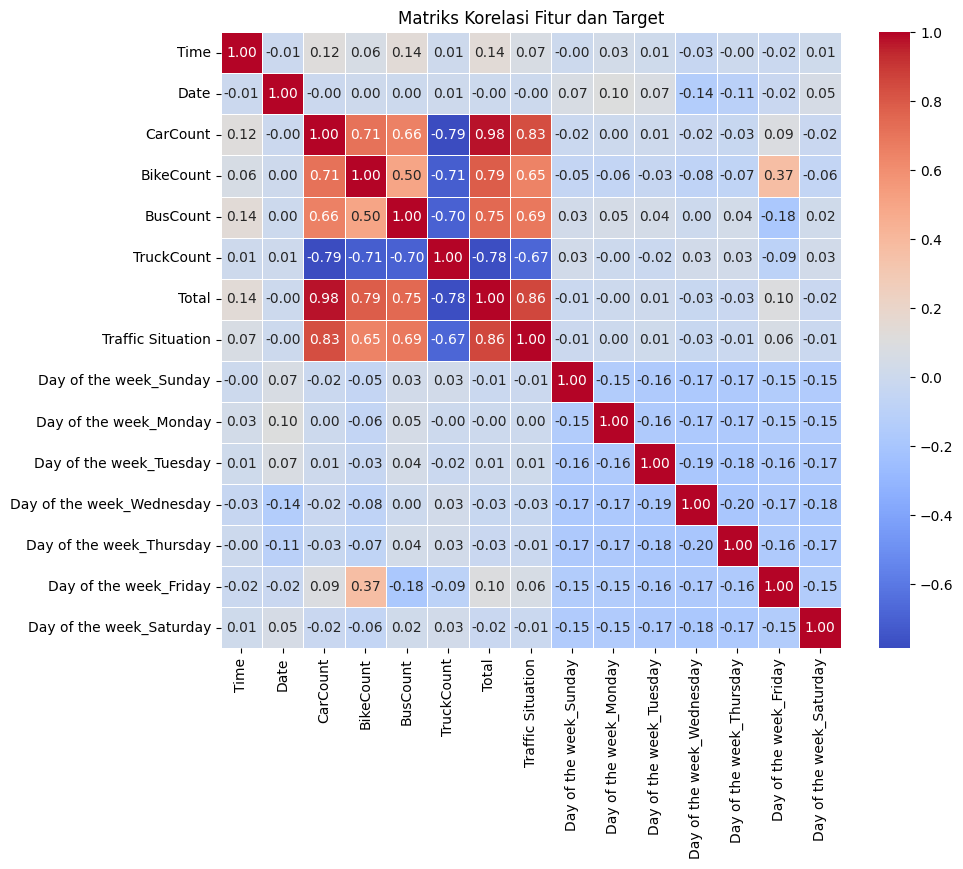

In [26]:
# ===================================
#   Menampilkan Heatmap Correlation
# ===================================

print("-"*60)
print("| Heatmap Correlation")
print("-"*60)

corr_matrix = df.corr()

# Korelasi variabel input dengan target
print("-"*5,"Korelasi dengan 'Traffic Situation':","-"*5,"\n")
print(corr_matrix['Traffic Situation'].sort_values(ascending=False),"\n")

# Visualisasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriks Korelasi Fitur dan Target')
plt.show()

In [27]:
# ========================================
#  Memisahkan Feature (X) dan Target (y)
# ========================================

print("-"*60)
print("| Pisahkan kolom fitur dan target")
print("-"*60)

# Feature X
drop_cols  = ["Total", "Date", "Traffic Situation"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
# Target y
y = df["Traffic Situation"]

feature_cols = list(set(df.columns) - set(drop_cols))
print("Semua Kolom       x",len(df.columns), ": ", list(df.columns))
print("kolom Feature (X) x", len(feature_cols), ": ", feature_cols)
print("kolom Target  (y) x", len([y.name]), ": ", [y.name])

------------------------------------------------------------
| Pisahkan kolom fitur dan target
------------------------------------------------------------
Semua Kolom       x 15 :  ['Time', 'Date', 'CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total', 'Traffic Situation', 'Day of the week_Sunday', 'Day of the week_Monday', 'Day of the week_Tuesday', 'Day of the week_Wednesday', 'Day of the week_Thursday', 'Day of the week_Friday', 'Day of the week_Saturday']
kolom Feature (X) x 12 :  ['Day of the week_Friday', 'CarCount', 'Day of the week_Tuesday', 'BikeCount', 'TruckCount', 'Day of the week_Saturday', 'Day of the week_Monday', 'Day of the week_Sunday', 'BusCount', 'Time', 'Day of the week_Wednesday', 'Day of the week_Thursday']
kolom Target  (y) x 1 :  ['Traffic Situation']


<br>

<h2>Tahap 3 - Training</h2>
<hr>

In [28]:
# =====================================
#  Pemisahan Data (train-test-split)
# =====================================


# Memisahkan data menjadi train set dan test set
# test_size=0.3 : 30% (test set) dan sisa 70% (train set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("-"*60)
print("| 4. Memisahkan train set dan test set")
print("-"*60)

print("Ukuran train-test fitur X: ")
print("Ukuran train set fitur (X_train):", X_train.shape)
print("Ukuran test set fitur (X_test):", X_test.shape)

print("\n")

print("Ukuran train-test fitur y: ")
print("Ukuran train set target (y_train):", y_train.shape)
print("Ukuran test set target (y_test):", y_test.shape)


print("\n","-"*5,"Head dari X_train:","-"*5)
display(X_train.head())

print("\n","-"*5,"Head dari y_train:","-"*5)
display(y_train.head())

------------------------------------------------------------
| 4. Memisahkan train set dan test set
------------------------------------------------------------
Ukuran train-test fitur X: 
Ukuran train set fitur (X_train): (1540, 12)
Ukuran test set fitur (X_test): (660, 12)


Ukuran train-test fitur y: 
Ukuran train set target (y_train): (1540,)
Ukuran test set target (y_test): (660,)

 ----- Head dari X_train: -----


,Time,CarCount,BikeCount,BusCount,TruckCount,Day of the week_Sunday,Day of the week_Monday,Day of the week_Tuesday,Day of the week_Wednesday,Day of the week_Thursday,Day of the week_Friday,Day of the week_Saturday
670,15,46,22,18,9,0,0,0,0,1,0,0
1700,15,148,64,27,0,0,0,0,0,0,1,0
1182,17,126,24,31,7,0,0,0,1,0,0,0
309,18,103,5,7,13,0,1,0,0,0,0,0
1144,7,132,25,40,2,1,0,0,0,0,0,0



 ----- Head dari y_train: -----


,Traffic Situation
670,0
1700,1
1182,1
309,0
1144,1


In [29]:
# ===================================
#     Melatih Model Random Forest
# ===================================

print("-"*60)
print("| Pelatihan Model Random Forest")
print("-"*60)

# Inisialisasi model Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Melatih model Random Forest...")
# Melatih model menggunakan data pelatihan
model.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih!\n")

print('-'*60)

------------------------------------------------------------
| Pelatihan Model Random Forest
------------------------------------------------------------
Melatih model Random Forest...
Model Random Forest berhasil dilatih!

------------------------------------------------------------


<br>

<h3>Tahap 4 - Evaluasi</h3>
<hr>

In [30]:
# ===================================
#   Evaluasi Hasil Training Model
# ===================================

print('-'*60)
print('| Perbandingan Evaluasi Model Random Forest')
print('-'*60)

# --- Random Forest Evaluation ---
print("\n--- Hasil Evaluasi Random Forest ---")
y_pred_rf = model.predict(X_test)
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
accuracy_rf = model.score(X_test, y_test)
print(f"Accuracy model Random Forest pada data uji: {accuracy_rf:.4f}")

------------------------------------------------------------
| Perbandingan Evaluasi Model Random Forest
------------------------------------------------------------

--- Hasil Evaluasi Random Forest ---
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       330
           1       0.97      0.98      0.98       330

    accuracy                           0.98       660
   macro avg       0.98      0.98      0.98       660
weighted avg       0.98      0.98      0.98       660

Accuracy model Random Forest pada data uji: 0.9773


------------------------------------------------------------
| Visualisasi Confusion Matrix
------------------------------------------------------------


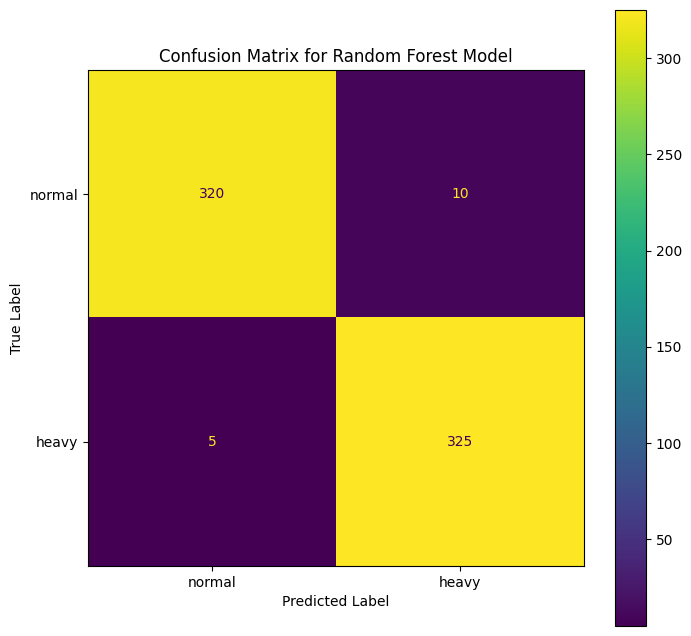


 KETERANGAN CONFUSION MATRIX (KELAS POSITIF & NEGATIF):
 * Kelas Negatif (0) : normal (Lalu lintas Lancar / Normal)
 * Kelas Positif (1) : heavy  (Lalu lintas Macet / Padat)
------------------------------------------------------------
 1. True Negative (TN)  : 320 data | Aktual lancar, diprediksi LANCAR.
 2. False Positive (FP) : 10 data  | Aktual lancar, diprediksi MACET (Salah Prediksi).
 3. False Negative (FN) : 5 data  | Aktual macet, diprediksi LANCAR (Salah Prediksi).
 4. True Positive (TP)  : 325 data | Aktual macet, diprediksi MACET.

------------------------------------------------------------


In [31]:
# ===================================
#    Menampilkan Confusion Matrix
# ===================================

print('-'*60)
print('| Visualisasi Confusion Matrix')
print('-'*60)

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Dapatkan label kelas dari mapping secara dinamis berdasarkan nilai unik di y_test
# Balikkan mapping untuk mencocokkan nilai numerik ke nama aslinya
reverse_mapping = {v: k for k, v in mapping.items()}
unique_classes = sorted(list(set(y_test.unique()) | set(y_pred_rf)))
class_labels = [reverse_mapping[c] for c in unique_classes]

# Visualisasikan confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='viridis', ax=ax, values_format='d')
plt.title('Confusion Matrix for Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Menambahkan catatan (notes) penjelasan kelas Positif dan Negatif
print('\n' + '='*60)
print(' KETERANGAN CONFUSION MATRIX (KELAS POSITIF & NEGATIF):')
print('='*60)
print(' * Kelas Negatif (0) : normal (Lalu lintas Lancar / Normal)')
print(' * Kelas Positif (1) : heavy  (Lalu lintas Macet / Padat)')
print('-'*60)
print(f' 1. True Negative (TN)  : {cm[0,0]} data | Aktual lancar, diprediksi LANCAR.')
print(f' 2. False Positive (FP) : {cm[0,1]} data  | Aktual lancar, diprediksi MACET (Salah Prediksi).')
print(f' 3. False Negative (FN) : {cm[1,0]} data  | Aktual macet, diprediksi LANCAR (Salah Prediksi).')
print(f' 4. True Positive (TP)  : {cm[1,1]} data | Aktual macet, diprediksi MACET.')
print('='*60)

print('\n' + '-'*60)

<br>
<h2>Tahap 5 - Inferensi</h2>
<hr>

In [ ]:
print('-'*60)
print('| Prediksi Klasifikasi Situasi Lalu Lintas')
print('-'*60)

# Mempersiapkan data input baru untuk inferensi dari input pengguna
# Pastikan urutan dan jumlah kolom sesuai dengan X_train

print("\nMasukkan nilai untuk fitur-fitur berikut:")

try:
    time_input = int(input("Time (Jam, 0-23): "))
    car_count_input = int(input("CarCount: "))
    bike_count_input = int(input("BikeCount: "))
    bus_count_input = int(input("BusCount: "))
    truck_count_input = int(input("TruckCount: "))
    day_of_week_input = input("Day of the week (Contoh: Monday, Tuesday, dll.): ").strip().capitalize()

    # Hitung total kendaraan secara otomatis untuk dijadikan fitur
    # total_input = car_count_input + bike_count_input + bus_count_input + truck_count_input

    # Buat DataFrame awal dengan nilai numerik dan fitur Total
    input_data_dict = {
        'Time': [time_input],
        'CarCount': [car_count_input],
        'BikeCount': [bike_count_input],
        'BusCount': [bus_count_input],
        'TruckCount': [truck_count_input],
        # 'Total': [total_input]
    }

    # Inisialisasi kolom one-hot encoding untuk hari dalam seminggu dengan 0
    day_columns = [col for col in X_train.columns if col.startswith('Day of the week_')]
    for day_col in day_columns:
        input_data_dict[day_col] = [0]

    # Buat DataFrame dari input yang diberikan
    new_data_input = pd.DataFrame(input_data_dict)

    # Setel nilai 1 untuk kolom hari yang sesuai dengan input pengguna
    day_col_name = f'Day of the week_{day_of_week_input}'
    if day_col_name in new_data_input.columns:
        new_data_input[day_col_name] = 1
    else:
        print(f"Peringatan: Hari '{day_of_week_input}' tidak dikenal atau tidak ada dalam data pelatihan. Pastikan ejaan benar.")

    # Pastikan urutan kolom sesuai dengan X_train
    new_data_input = new_data_input[X_train.columns]

    print("\nData Input Baru untuk Prediksi:")
    display(new_data_input)

    # Lakukan prediksi menggunakan model Random Forest yang sudah dilatih (model)
    predicted_class_encoded = model.predict(new_data_input)

    # Balikkan mapping untuk mendapatkan label kelas asli
    reverse_mapping = {v: k for k, v in mapping.items()}
    predicted_class_label = reverse_mapping[predicted_class_encoded[0]]

    print(f"\nKlasifikasi Lalu lintas: {predicted_class_label}")

except ValueError:
    print("Input tidak valid. Pastikan semua input numerik adalah angka dan format jam benar.")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")

print('\n' + '-'*60)

------------------------------------------------------------
| Prediksi Klasifikasi Situasi Lalu Lintas
------------------------------------------------------------

Masukkan nilai untuk fitur-fitur berikut:
